# Практика

Мы пока что не умеем работать с аудиоинформацией и преобразовывать её в привычный нам формат табличных данных, поэтому для решения данной задачи мы нашли готовый датасет, в котором все преобразования аудиоинформации в числовой табличный формат уже произведены.

Набор данных состоит из 3 168 записанных образцов голоса мужчин и женщин. Образцы предварительно обрабатываются с помощью акустического анализа на языке программирования R с использованием специальных библиотек в диапазоне частот 0 Гц-280 Гц (диапазон человеческого голоса). Если вкратце, в результате обработки звук на аудиозаписи оцифровывается и преобразуется в числовую последовательность частот, из которой извлекаются различные статистические характеристики, например средняя частота, с которой говорит спикер на аудиозаписи, или частота с наибольшей энергией и так далее.

In [1]:
#Загрузим необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics

In [3]:
#Загрузим и прочитаем датафрейм
voice_data = pd.read_csv('data/voice_gender.csv')
display(voice_data.head())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [4]:
#Выведем информацию
display(voice_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

None

Итак, все признаки, за исключением целевого, кодируются числовым форматом. Типизация целевой переменной не имеет значения для моделей машинного обучения в библиотеке sklearn, поэтому кодирование категориальных признаков нам не потребуется.

Заодно проверим данные на наличие пропусков:

In [6]:
voice_data.isnull().sum().sum()

0

In [7]:
#Разобъем датасет на X и y
X = voice_data.drop(columns='label')
y = voice_data['label']

Разделим датасет на две части в соотношении 80/20:

In [8]:
#Формируем обучающую и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2,
                                                                    stratify=y, random_state=42)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2534, 20)
Test shape: (634, 20)


### Задание 7.1
Начнём с решающего пня.

Создайте модель дерева решений максимальной глубины 1. В качестве критерия информативности используйте энтропию Шеннона.

Обучите модель на тренировочной выборке и визуализируйте её в виде графа.

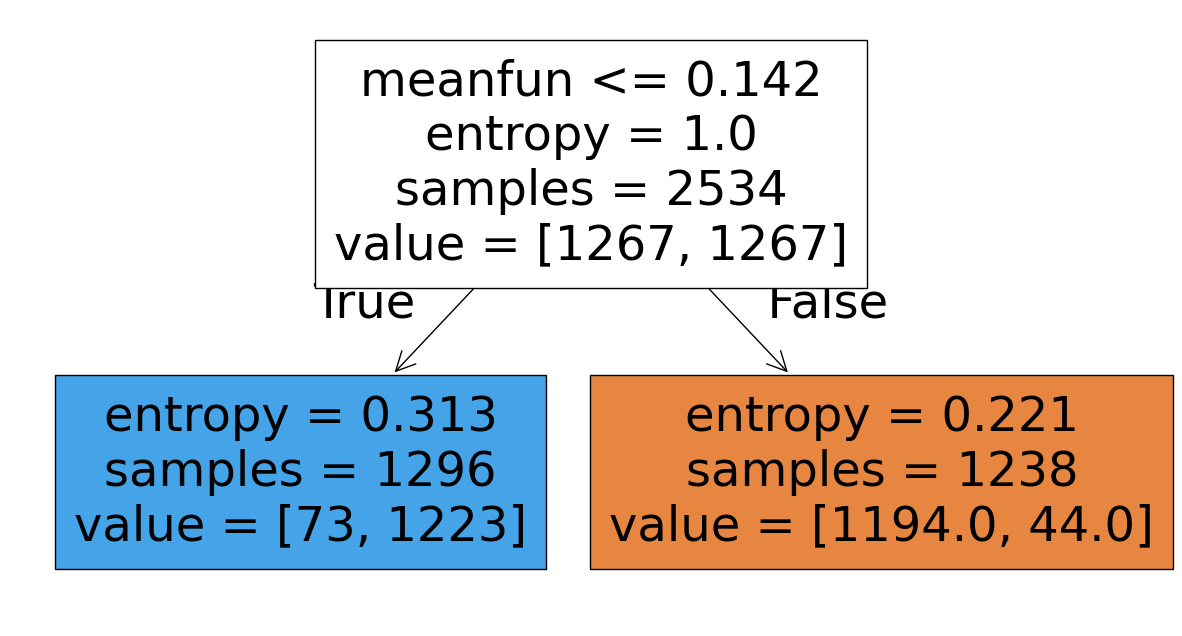

In [22]:
# Инициализируем модель дерева решений и обучаем ее
dt = tree.DecisionTreeClassifier(
    max_depth=1,
    criterion='entropy', #критерий информативности
    random_state=42 #генератор случайных чисел
)
dt.fit(X_train, y_train)
# Визуализируем дерево решений в виде графа
fig, ax = plt.subplots(figsize=(15, 8))
tree.plot_tree(dt, feature_names=X.columns, filled=True, ax=ax);

In [23]:
#Делаем предсказание для пня глубиной 1
y_pred = dt.predict(X_test)

#Загружаем необходимую библиотеку
from sklearn.metrics import accuracy_score

#Проверяем качество метрики Accuracy для пня глубиной 1
print(f"Accuracy with max_depth = 1: {round(accuracy_score(y_test, y_pred),3)}")

Accuracy with max_depth = 1: 0.956


### Задание 7.2
Увеличим глубину дерева.

Создайте дерево решений с максимальной глубиной 2. В качестве критерия информативности используйте энтропию Шеннона.

Обучите модель на тренировочной выборке и визуализируйте её в виде графа.

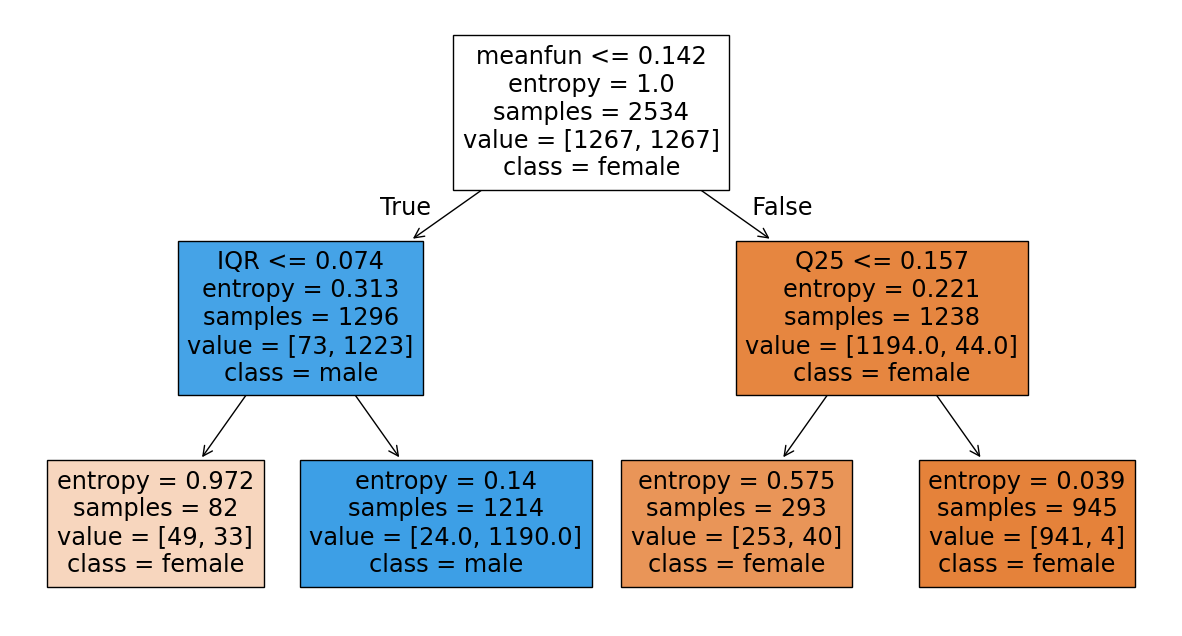

In [34]:
# Инициализируем модель дерева решений и обучаем ее
dt = tree.DecisionTreeClassifier(
    max_depth=2,
    criterion='entropy', #критерий информативности
    random_state=42 #генератор случайных чисел
)
dt.fit(X_train, y_train)
# Визуализируем дерево решений в виде графа
fig, ax = plt.subplots(figsize=(15, 8))
tree.plot_tree(dt, feature_names=X.columns, filled=True, ax=ax, class_names=dt.classes_);

In [35]:
#Делаем предсказание для дерева глубиной 2
y_pred = dt.predict(X_test)

#Проверяем качество метрики Accuracy для дерева глубиной 2
print(f"Accuracy with max_depth = 2: {round(accuracy_score(y_test, y_pred),3)}")

Accuracy with max_depth = 2: 0.962


### Задание 7.3
Давайте дадим дереву решений полную свободу.

Создайте дерево решений, не ограничивая его максимальную глубину. В качестве критерия информативности используйте энтропию Шеннона.

В качестве значения параметра random_state возьмите 0.

Обучите модель на тренировочной выборке.

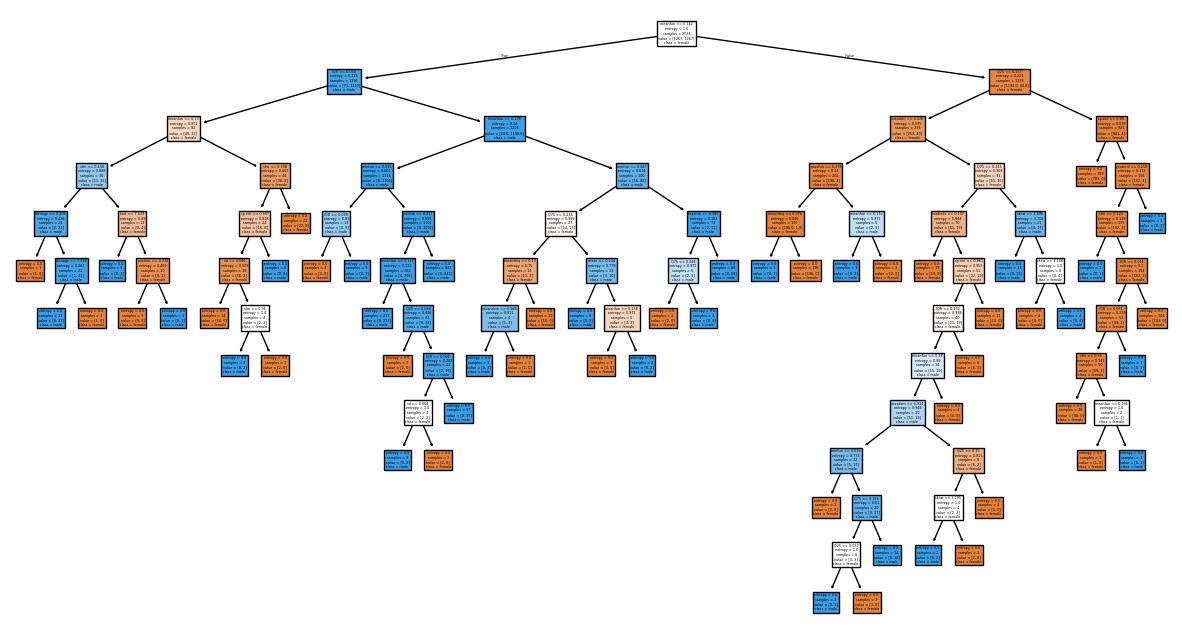

In [36]:
# Инициализируем модель дерева решений и обучаем ее
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=0 #генератор случайных чисел
)
dt.fit(X_train, y_train)
# Визуализируем дерево решений в виде графа
fig, ax = plt.subplots(figsize=(15, 8))
tree.plot_tree(dt, feature_names=X.columns, filled=True, ax=ax, class_names=dt.classes_);

In [37]:
#Определяем глубину дерева решений
print(f"Глубина дерева решений: {dt.get_depth()}")

#Определяем количество листьев в дереве
print(f"Количество листьев в дереве решений: {dt.get_n_leaves()}")

Глубина дерева решений: 12
Количество листьев в дереве решений: 54


In [38]:
#Делаем предсказание на обучающей и тестовой выборок
#для дерева без ограничений
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

#Проверяем качество метрики Accuracy для обучающей и тестовой выборок
#для дерева без ограничений
print(f"Accuracy : {round(accuracy_score(y_train, y_pred_train),3)}")
print(f"Accuracy : {round(accuracy_score(y_test, y_pred_test),3)}")

Accuracy : 1.0
Accuracy : 0.973


### Задание 7.4
Давайте попробуем найти оптимальные внешние параметры модели дерева решений для поставленной задачи. Воспользуемся классическим методом подбора гиперпараметров — перебором на сетке с кросс-валидацией (Grid SearchCV).

Задана следующая сетка параметров:

In [39]:
# Задаём сетку параметров
param_grid = {
    'criterion': ['gini', 'entropy'], #критерий информативности
    'max_depth': [4, 5, 6, 7, 8, 9, 10], #максимальная глубина дерева
    'min_samples_split': [3, 4, 5, 10] #минимальное количество объектов, необходимое для сплита
}

В качестве кросс-валидатора будем использовать k-fold-валидатор со стратификацией (StratifiedKFold):

In [40]:
# Задаём метод кросс-валидации
cv = model_selection.StratifiedKFold(n_splits=5)

С помощью Grid SearchCV из модуля model_selection библиотеки sklearn переберите гиперпараметры дерева решений из приведённой сетки на обучающей выборке и найдите оптимальные. Параметр random_state для дерева решений установите равным 0. В качестве метрики качества (параметр scoring) используйте accuracy.

In [43]:
#Загружаем необходимую библиотеку
from sklearn.model_selection import GridSearchCV

#Реализация gridsearchcv
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv
)
grid_search.fit(X_train, y_train)

# Вывод результатов
print("Лучшие параметры:", grid_search.best_params_)


Лучшие параметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 3}


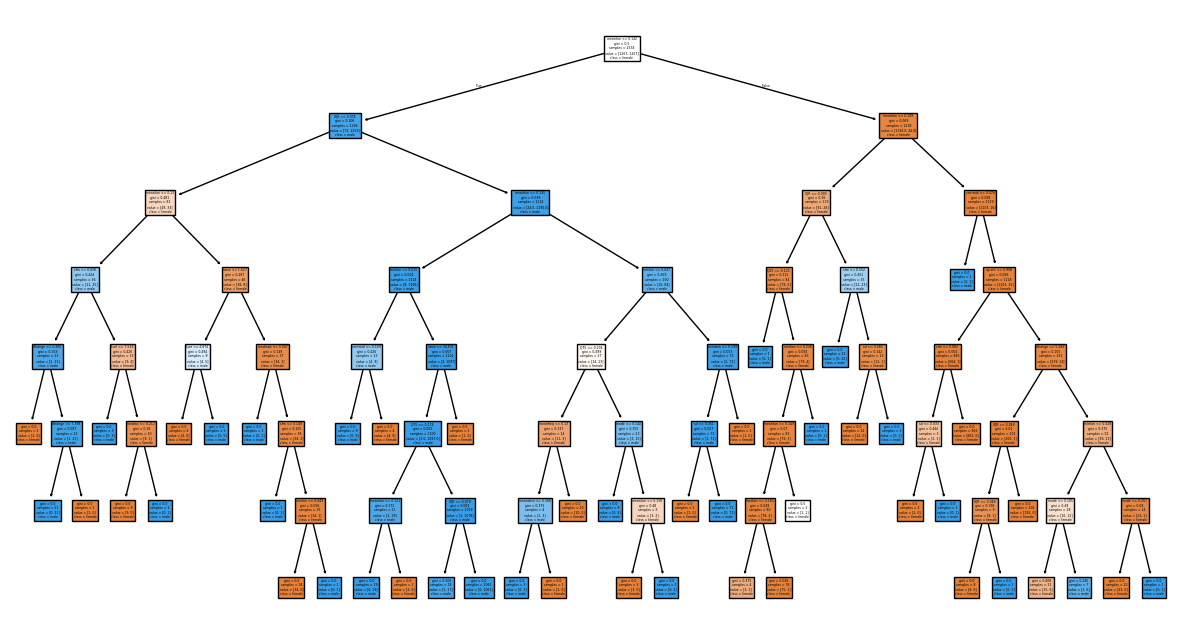

In [44]:
# Инициализируем модель дерева решений и обучаем ее
dt = tree.DecisionTreeClassifier(
    criterion='gini', #критерий информативности
    random_state=0, #генератор случайных чисел
    max_depth=7,
    min_samples_split=3
)

dt.fit(X_train, y_train)

# Визуализируем дерево решений в виде графа
fig, ax = plt.subplots(figsize=(15, 8))
tree.plot_tree(dt, feature_names=X.columns, filled=True, ax=ax, class_names=dt.classes_);

In [45]:
#Делаем предсказание на обучающей и тестовой выборок
#для дерева c лучшими параметрами
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

#Проверяем качество метрики Accuracy для обучающей и тестовой выборок
#для для дерева c лучшими параметрами
print(f"Accuracy : {round(accuracy_score(y_train, y_pred_train),3)}")
print(f"Accuracy : {round(accuracy_score(y_test, y_pred_test),3)}")

Accuracy : 0.996
Accuracy : 0.97


### Задание 7.5
Для оптимального дерева решений, построенного в задании 7.4, найдите важность каждого из факторов. Визуализируйте её в виде столбчатой диаграммы.

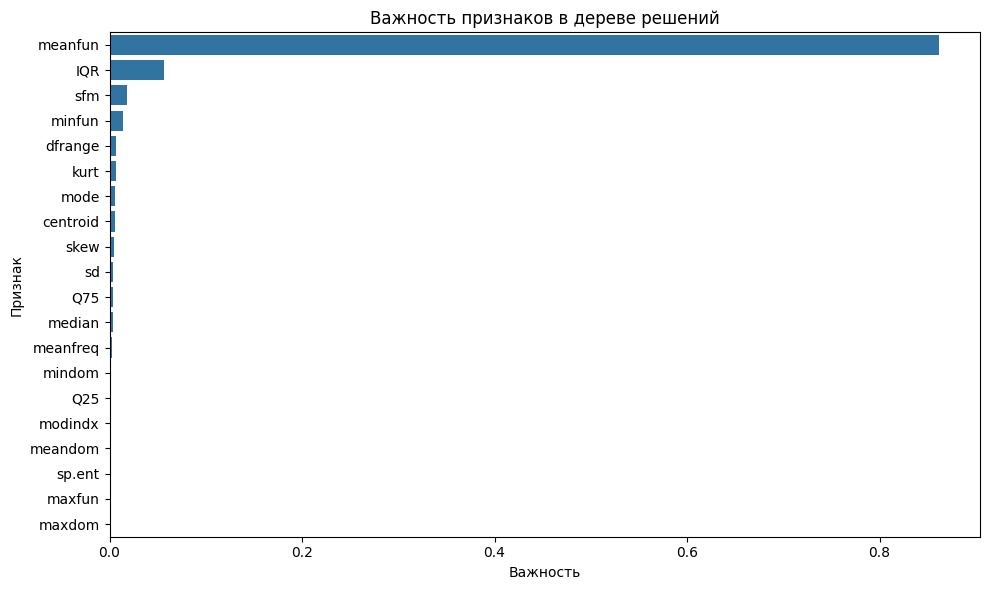

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(dt.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, ax=ax)
ax.set_xlabel('Важность')
ax.set_ylabel('Признак')
ax.set_title('Важность признаков в дереве решений')
plt.tight_layout()